In [1]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import accuracy_score
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# Lire le CSV
df = pd.read_csv("data/df_num_cleaned.csv")

<Axes: >

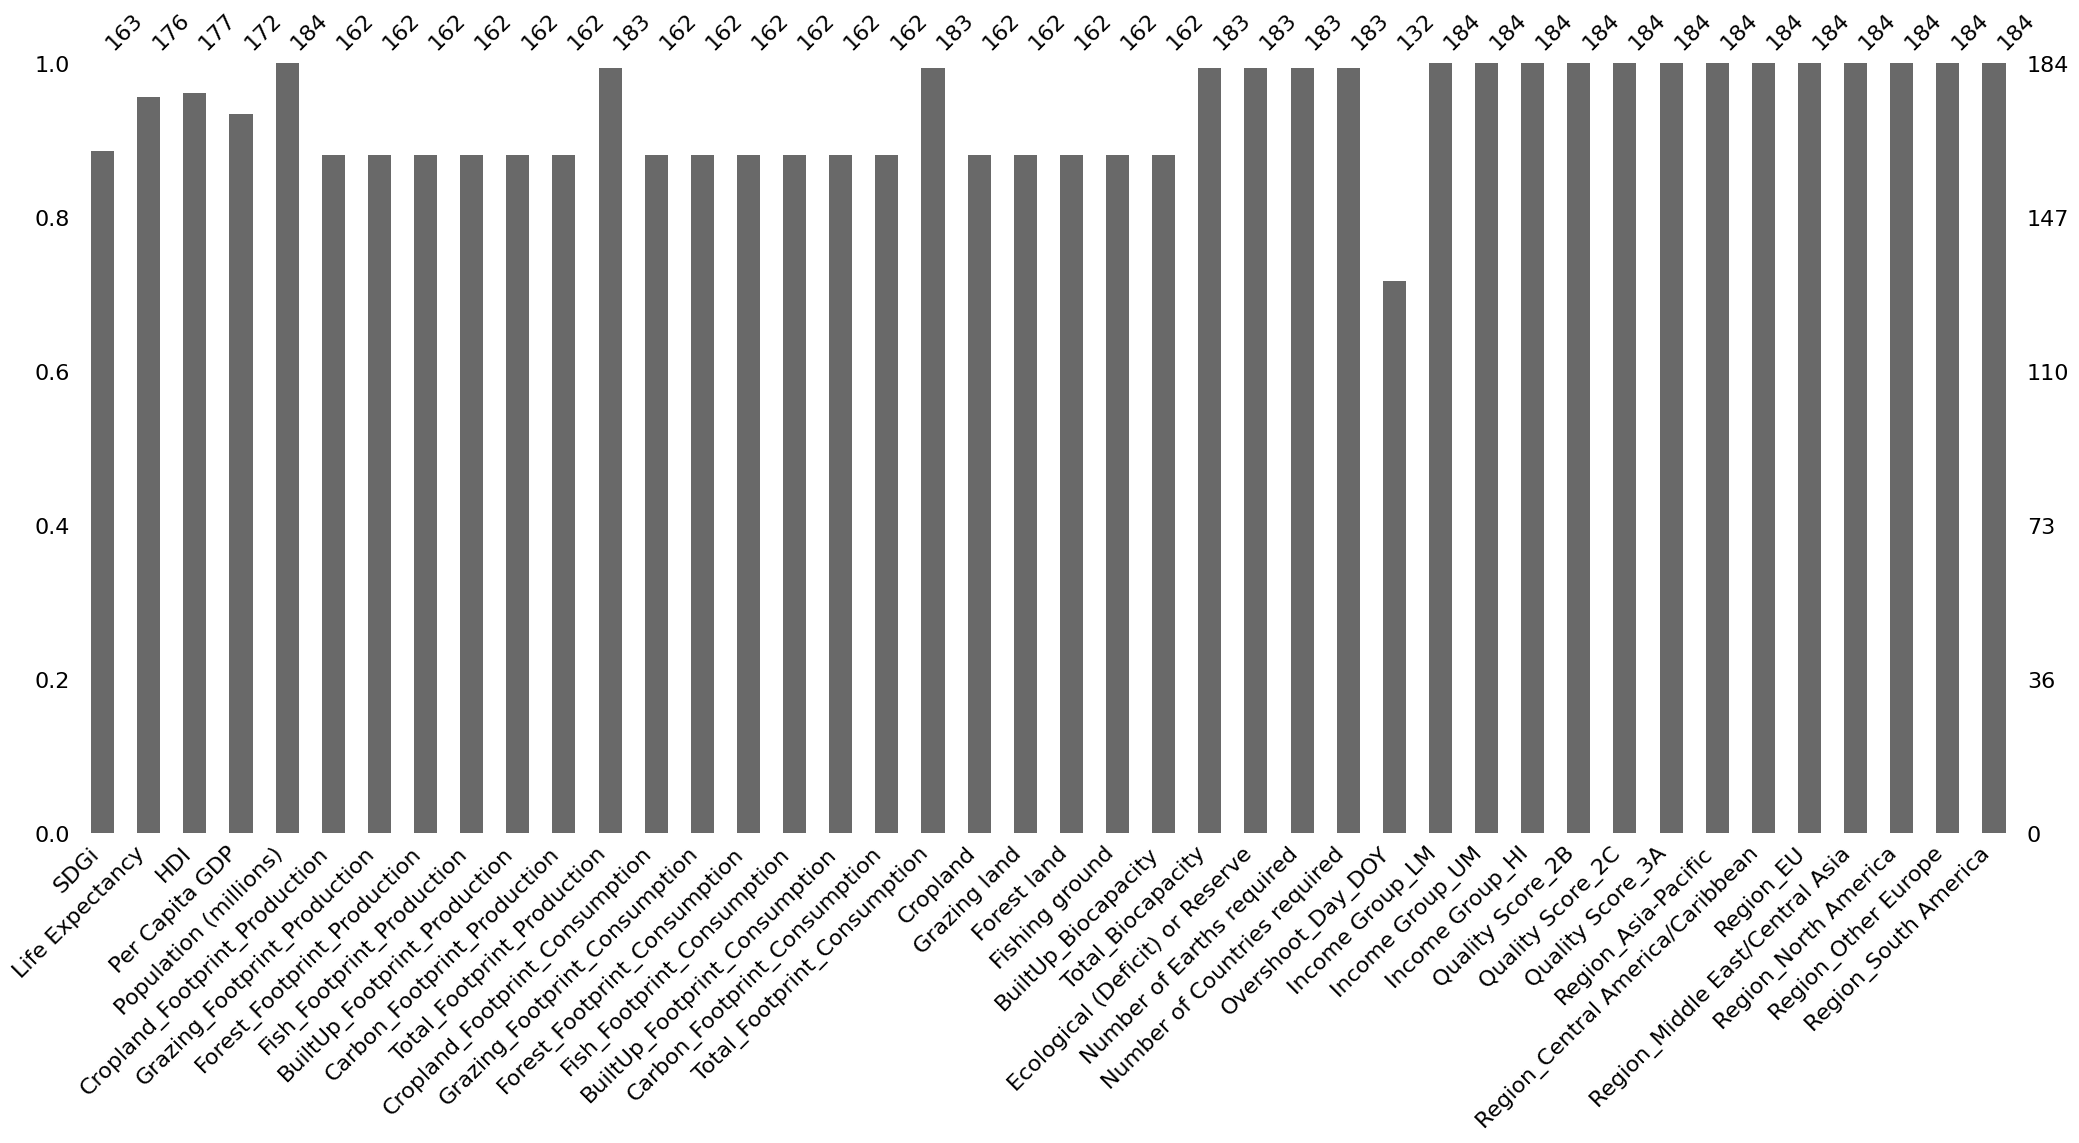

In [4]:
#give a barplot of the missing values
msno.bar(df)

On voit que la colonne qui possède le plus de données manquante est Overshoot day.
On a 18 variables pour qui il manque environ 10% des data.
3 variables pour qui il manque moins de 10% des variables.
Le reste des variables est complet (20 variables).

<Axes: >

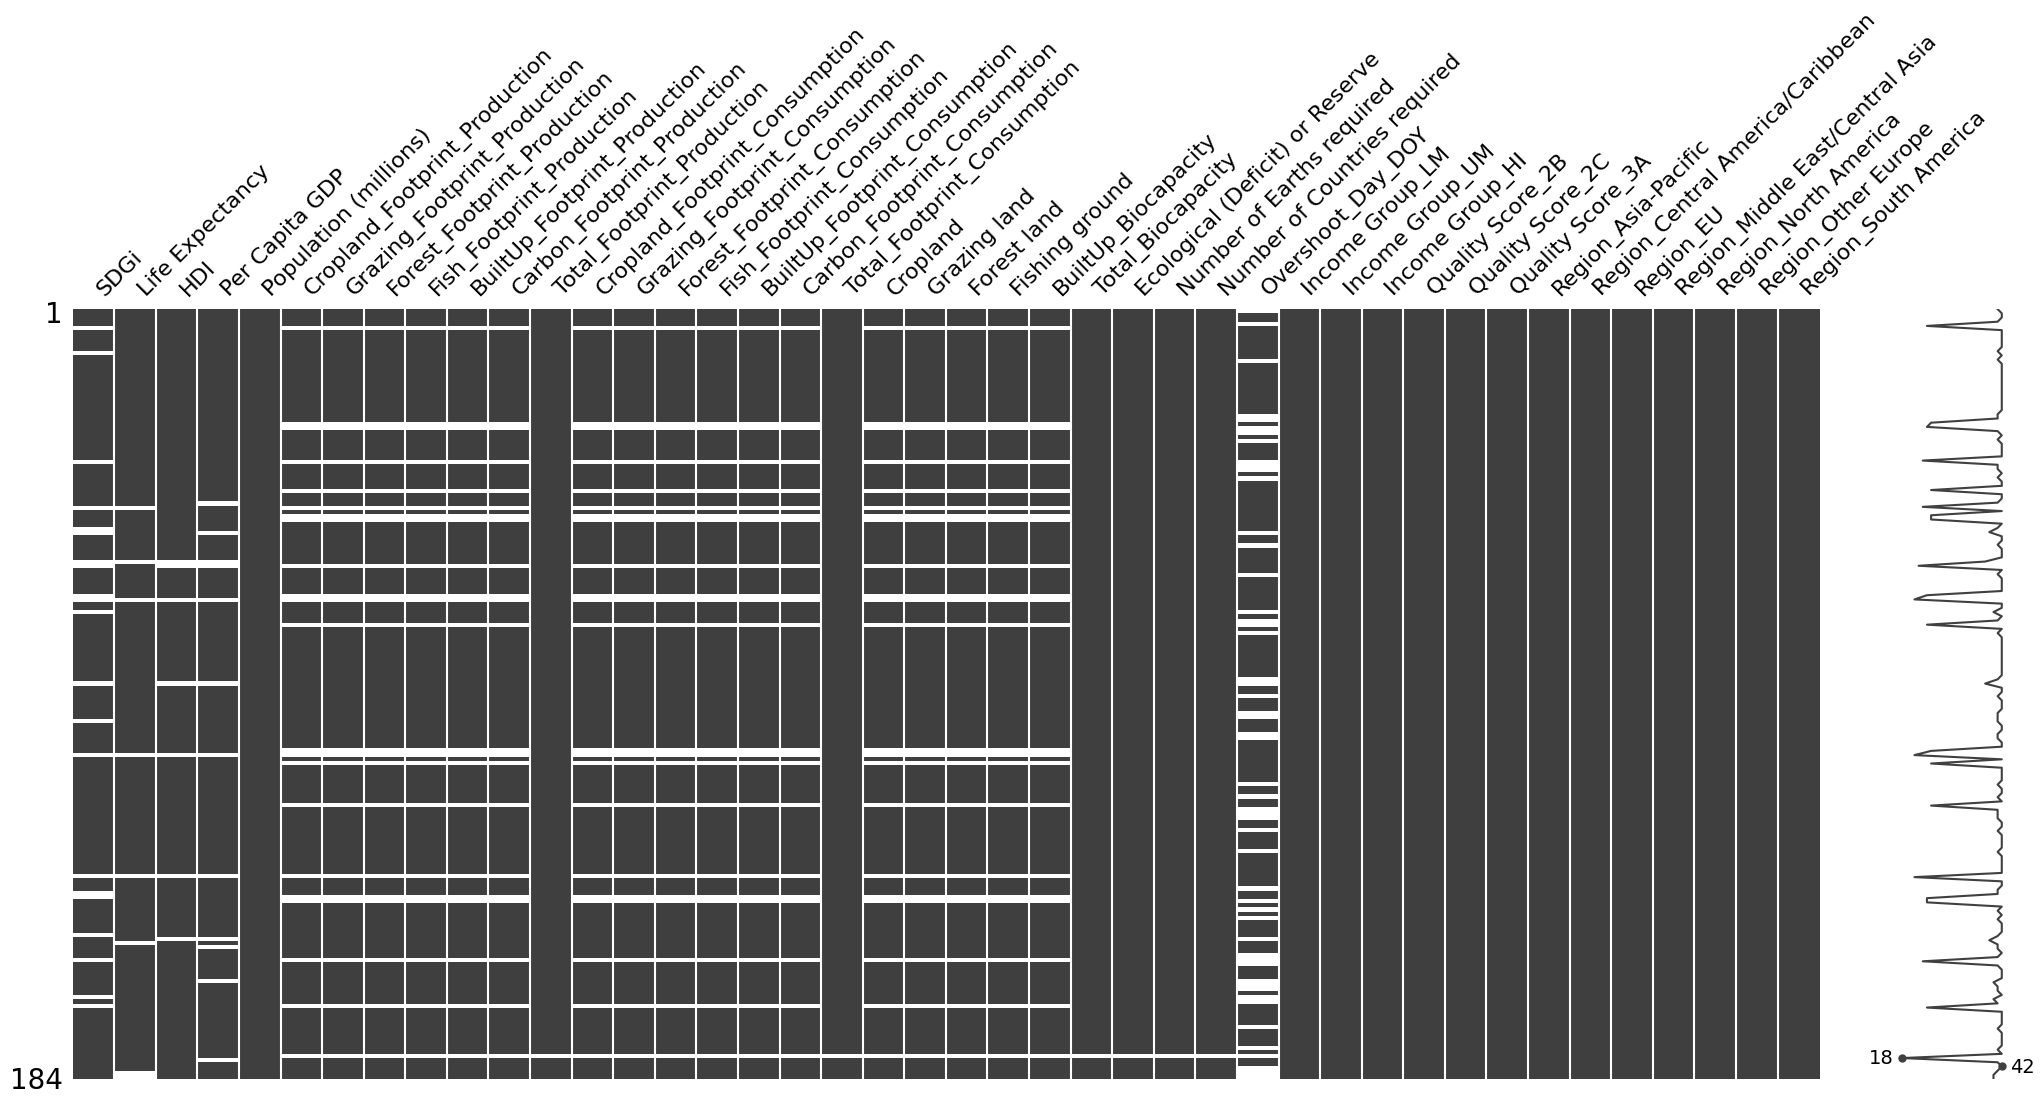

In [5]:
msno.matrix(df)

Lorsqu'on a un pays avec des NA, dans la plupart des cas, le pays possède des NA dans plusieurs variables différentes. 
=> ça semble vouloir dire que ce n'est pas dû au hasard donc plutôt MNAR ou MAR.

On voit aussi qu'on a les totaux des footprint consumption et footprint production, mais pas forcément les variables qui ont permis de calculer ces totaux.
=> dépendance entre les variables manquantes
=> Donc on peut pas traiter les NA indépendamment.

On a des colonnes avec aucunes données manquantes.
=> Peuvent être utiles pour l'imputation ou les modèles.

On peut voir aussi que la répartition des NA est hétérogène, certains pays n'ont pas de NA et d'autre n'ont quasiment que des NA.

<Axes: >

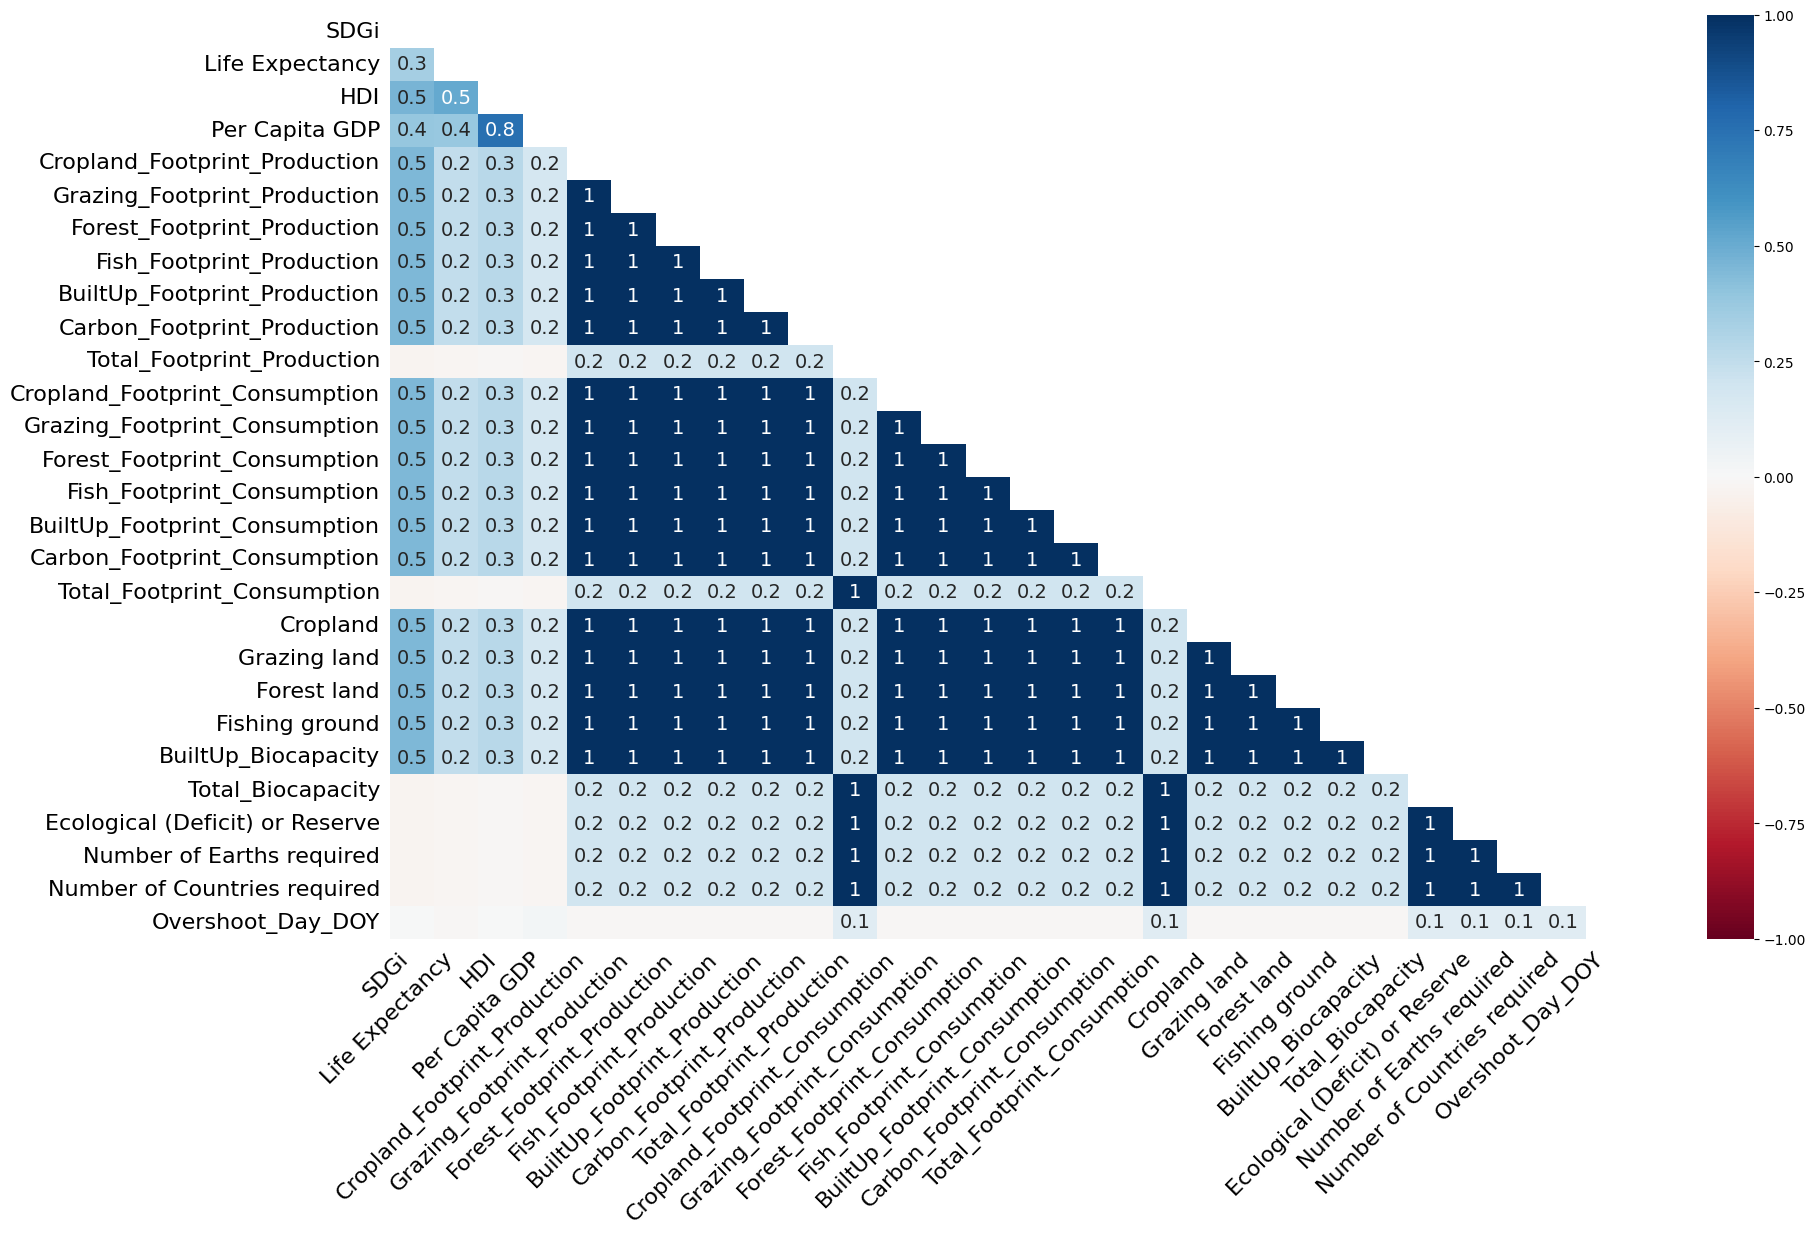

In [6]:
msno.heatmap(df)

They represent how correlated the fact that having null values in ones variable affect having null values in the second one.

Exemple: If you know where the null values in fishing ground are, that completely determines the null values in Cropland_footprint_Production.

Globalement: On voit qu'il y a beaucoup de 1 dans notre matrice => beaucoup de dépendance entre les NA au sein de notre jeu de données.